For a Mac

1. run in default terminal:<br>
R                              # to enter R environment <br>
install.packages('IRkernel')   # it will ask you to select an install mirror<br>
IRkernel::installspec()<br>

2. Restart VScode
3. open an ipynb, click select kernel (in the top right corner) -> Jupyter kernel -> R


---

# Model Evaluation Metrics



METHODS COVERED:
  1. LASSO (Least Absolute Shrinkage and Selection Operator) — Section 3
   2. Ridge Regression                                        — Section 3
   3. Random Forests                                         — Section 5
   4. Neural Networks (MLP)                                  — Section 6
   5. Support Vector Regression — not in any Section notes

 STRUCTURE:
  * Part A  — Shared regression metrics (MSE, MAE, RMSE, R², Hit Ratio)
   * Part B  — Shared classification metrics (Confusion matrix, AUC, F1)
   * Part C  — LASSO-specific metrics (path, variable selection, cross-val)
   * Part D  — Ridge-specific metrics (bias-variance decomposition)
   * Part E  — Random Forest-specific metrics (OOB error, variable importance)
   * Part F  — Neural Network-specific metrics (learning curves, calibration)
   * PART G — Support vector-specific metrics (information coefficient, Theil's U)
   * Part H  — Portfolio-level metrics (Sharpe, turnover, drawdown)

In [6]:
# DEPENDENCIES:
#   install.packages(c("glmnet","randomForest","keras","tensorflow",
#                      "caTools","pROC","e1071","ggplot2","dplyr"))

In [1]:
install.packages(c("glmnet","randomForest","keras","tensorflow","caTools","pROC","e1071","ggplot2","dplyr"))

also installing the dependencies 'lifecycle', 'vctrs'





The downloaded binary packages are in
	/var/folders/tz/0pg3_6s57f39kds6_g4kpl680000gn/T//Rtmp8WRXTw/downloaded_packages


### PART A — SHARED REGRESSION METRICS

In [ ]:
# -----------------------------------------------------------------------------
# A1. Mean Squared Error (MSE)
# -----------------------------------------------------------------------------
compute_mse <- function(y_true, y_pred) {
  # Arguments:
  #   y_true : numeric vector of realized values (e.g., monthly returns)
  #   y_pred : numeric vector of model predictions (same length)
  #
  # Returns: scalar — mean squared prediction error
 
  stopifnot(length(y_true) == length(y_pred))
  mse <- mean((y_true - y_pred)^2)
 
  # Decompose into components as discussed in Section 7
  term_realized  <- mean(y_true^2)
  term_predicted <- mean(y_pred^2)
  cross_term     <- -2 * mean(y_true * y_pred)
 
  cat("MSE decomposition:\n")
  cat("  MSE (total)      :", round(mse, 6), "\n")
  cat("  E[y²] (fixed)    :", round(term_realized, 6), "\n")
  cat("  E[ŷ²] (variance) :", round(term_predicted, 6), "\n")
  cat("  -2·E[y·ŷ] (cross):", round(cross_term, 6), "\n")
  cat("  Note: for portfolio use, cross-term is most informative\n")
 
  return(invisible(mse))
}
 
 
# -----------------------------------------------------------------------------
# A2. Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE)
# -----------------------------------------------------------------------------
compute_rmse_mae <- function(y_true, y_pred, label = "Model") {
  # Arguments:
  #   y_true : numeric vector of realized values
  #   y_pred : numeric vector of model predictions
  #   label  : character string for display (default "Model")
  #
  # Returns: named numeric vector with MAE and RMSE
 
  stopifnot(length(y_true) == length(y_pred))
 
  mae  <- mean(abs(y_true - y_pred))
  rmse <- sqrt(mean((y_true - y_pred)^2))
 
  # Naive benchmark: always predict zero (relevant for return prediction)
  mae_naive  <- mean(abs(y_true))
  rmse_naive <- sqrt(mean(y_true^2))
 
  cat(label, "vs. zero-prediction benchmark:\n")
  cat("  MAE  — model:", round(mae, 6),
      "| naive:", round(mae_naive, 6),
      "| skill:", round(1 - mae / mae_naive, 3), "\n")
  cat("  RMSE — model:", round(rmse, 6),
      "| naive:", round(rmse_naive, 6),
      "| skill:", round(1 - rmse / rmse_naive, 3), "\n")
 
  return(invisible(c(MAE = mae, RMSE = rmse)))
}
 
 
# -----------------------------------------------------------------------------
# A3. Out-of-Sample R² (OOS R²)
# -----------------------------------------------------------------------------
compute_oos_r2 <- function(y_true, y_pred, include_mean_benchmark = FALSE) {
  # Arguments:
  #   y_true                : numeric vector of realized values
  #   y_pred                : numeric vector of OOS predictions
  #   include_mean_benchmark: logical — if TRUE, denominator uses sample mean
  #                           (classical R²); if FALSE, denominator uses zero
  #                           (preferred for return prediction, Section 7)
  #
  # Returns: scalar — OOS R²
 
  stopifnot(length(y_true) == length(y_pred))
 
  numerator <- sum((y_true - y_pred)^2)
 
  if (include_mean_benchmark) {
    denominator <- sum((y_true - mean(y_true))^2)
    bench_label <- "mean prediction"
  } else {
    denominator <- sum(y_true^2)        # Equivalent to predicting zero
    bench_label <- "zero prediction"
  }
 
  r2 <- 1 - numerator / denominator
 
  cat("OOS R² (benchmark:", bench_label, "):", round(r2, 4), "\n")
  if (r2 < 0) cat("  [Note: model is worse than the", bench_label, "benchmark]\n")
 
  return(invisible(r2))
}
 
 
# -----------------------------------------------------------------------------
# A4. Hit Ratio (Directional Accuracy)
# -----------------------------------------------------------------------------
compute_hit_ratio <- function(y_true, y_pred, long_only = FALSE) {
  # Arguments:
  #   y_true    : numeric vector of realized values
  #   y_pred    : numeric vector of predictions
  #   long_only : logical — if TRUE, use the positive-return frequency as
  #               benchmark (appropriate for long-only strategies); if FALSE,
  #               use 50% (appropriate for long-short strategies)
  #
  # Returns: named vector with hit ratio and benchmark context
 
  stopifnot(length(y_true) == length(y_pred))
 
  hit_ratio <- mean(sign(y_pred) == sign(y_true))
  pos_freq  <- mean(y_true > 0)     # Fraction of periods with positive returns
 
  benchmark <- if (long_only) pos_freq else 0.5
  bench_label <- if (long_only) "positive-return frequency" else "50% (long-short)"
 
  cat("Hit ratio         :", round(hit_ratio, 4), "\n")
  cat("Benchmark (", bench_label, "):", round(benchmark, 4), "\n")
  cat("Excess over bench :", round(hit_ratio - benchmark, 4), "\n")
  if (hit_ratio < benchmark) {
    cat("  [Warning: model does not beat the naive benchmark]\n")
  }
 
  return(invisible(c(hit_ratio = hit_ratio, benchmark = benchmark)))
}

### PART B — SHARED CLASSIFICATION METRICS

In [ ]:
# -----------------------------------------------------------------------------
# B1. Confusion Matrix and Derived Metrics
# -----------------------------------------------------------------------------
compute_confusion_metrics <- function(y_true, y_pred_class,
                                      positive_label = 1) {
  # Arguments:
  #   y_true         : factor or integer vector of true classes
  #   y_pred_class   : factor or integer vector of predicted classes
  #   positive_label : the value treated as "positive" (default 1)
  #
  # Returns: list of all binary classification metrics from Section 7
 
  y_true       <- as.integer(y_true       == positive_label)
  y_pred_class <- as.integer(y_pred_class == positive_label)
 
  tp <- mean(y_true == 1 & y_pred_class == 1)   # True positive rate (frequency)
  tn <- mean(y_true == 0 & y_pred_class == 0)   # True negative rate
  fp <- mean(y_true == 0 & y_pred_class == 1)   # False positive (Type I error)
  fn <- mean(y_true == 1 & y_pred_class == 0)   # False negative (Type II error)
 
  accuracy    <- tp + tn
  recall      <- tp / (tp + fn + 1e-12)           # Sensitivity / TPR
  precision   <- tp / (tp + fp + 1e-12)           # Positive predictive value
  specificity <- tn / (tn + tp + 1e-12)           # True negative rate
  fallout     <- fp / (fp + tn + 1e-12)           # False positive rate = 1 - specificity
  f1          <- 2 * recall * precision / (recall + precision + 1e-12)
 
  cat("=== Confusion Matrix Metrics (Section 7) ===\n")
  cat("  TP frequency :", round(tp, 4), "  (invested, worked)\n")
  cat("  TN frequency :", round(tn, 4), "  (excluded, correct)\n")
  cat("  FP frequency :", round(fp, 4), "  (Type I  — invested, failed)\n")
  cat("  FN frequency :", round(fn, 4), "  (Type II — excluded, missed)\n")
  cat("  ---\n")
  cat("  Accuracy    :", round(accuracy,    4), "\n")
  cat("  Recall      :", round(recall,      4), "  (TPR / sensitivity)\n")
  cat("  Precision   :", round(precision,   4), "\n")
  cat("  Specificity :", round(specificity, 4), "\n")
  cat("  Fallout     :", round(fallout,     4), "  (FPR = 1 - specificity)\n")
  cat("  F1 score    :", round(f1,          4), "\n")
 
  return(invisible(list(tp = tp, tn = tn, fp = fp, fn = fn,
                        accuracy = accuracy, recall = recall,
                        precision = precision, specificity = specificity,
                        fallout = fallout, f1 = f1)))
}
 
 
# -----------------------------------------------------------------------------
# B2. ROC Curve and Area Under the Curve (AUC)
# -----------------------------------------------------------------------------
compute_roc_auc <- function(y_true, y_prob, positive_label = 1,
                            plot_roc = TRUE) {
  # Arguments:
  #   y_true         : true binary labels
  #   y_prob         : predicted probabilities of belonging to the positive class
  #   positive_label : value treated as positive
  #   plot_roc       : logical — whether to draw the ROC curve
  #
  # Requires: caTools package (as used in the course code)
  # Returns:  AUC scalar
 
  if (!requireNamespace("caTools", quietly = TRUE)) {
    stop("Package 'caTools' required. Run: install.packages('caTools')")
  }
 
  y_bin <- as.integer(as.character(y_true) == as.character(positive_label))
  prob_mat <- cbind(`0` = 1 - y_prob, `1` = y_prob)
 
  auc <- caTools::colAUC(X = prob_mat, y = y_bin, plotROC = plot_roc)
 
  cat("AUC:", round(auc[2], 4),
      "| Interpretation:",
      ifelse(auc[2] >= 0.7, "acceptable",
             ifelse(auc[2] >= 0.5, "weak — close to random", "worse than random")),
      "\n")
 
  return(invisible(auc[2]))
}

### PART C — LASSO-SPECIFIC METRICS

In [ ]:
# Section 3 introduces LASSO as an L1-penalized regression
# that minimises SSE + λ·Σ|β_j|. Unlike Ridge, LASSO drives coefficients
# exactly to zero, providing variable selection. The course uses glmnet
# (alpha=1 for LASSO, alpha=0 for Ridge, 0<alpha<1 for Elastic Net).
 
# -----------------------------------------------------------------------------
# C1. LASSO Regularisation Path
# -----------------------------------------------------------------------------
evaluate_lasso_path <- function(x_matrix, y_vector, n_lambda = 100,
                                alpha = 1, plot_path = TRUE) {
  # Arguments:
  #   x_matrix  : numeric matrix of predictors (T × p), pre-scaled
  #   y_vector  : numeric response vector (T × 1), e.g., monthly returns
  #   n_lambda  : number of penalty values to evaluate (default 100)
  #   alpha     : mixing parameter — 1 = LASSO, 0 = Ridge, (0,1) = Elastic Net
  #   plot_path : logical — if TRUE, draw the regularisation path
  #
  # Returns: fitted glmnet object
 
  if (!requireNamespace("glmnet", quietly = TRUE)) {
    stop("Package 'glmnet' required. Run: install.packages('glmnet')")
  }
 
  fit <- glmnet::glmnet(x_matrix, y_vector, alpha = alpha,
                        nlambda = n_lambda, standardize = FALSE)
 
  # Count non-zero coefficients at each lambda (sparsity profile)
  n_nonzero <- apply(fit$beta != 0, 2, sum)
  cat("LASSO path summary (alpha =", alpha, "):\n")
  cat("  Lambda range     : [", round(min(fit$lambda), 6), ",",
      round(max(fit$lambda), 6), "]\n")
  cat("  Max non-zero coef:", max(n_nonzero), "\n")
  cat("  Min non-zero coef:", min(n_nonzero), "\n")
 
  if (plot_path) {
    plot(fit, xvar = "lambda", label = TRUE,
         main = paste0("Regularisation path (alpha = ", alpha, ")"),
         xlab = "log(λ)",
         ylab = "Coefficient estimate")
    abline(h = 0, lty = 2, col = "grey60")
  }
 
  return(invisible(fit))
}
 
 
# -----------------------------------------------------------------------------
# C2. Cross-Validated Lambda Selection for LASSO
# -----------------------------------------------------------------------------
select_lasso_lambda <- function(x_matrix, y_vector, nfolds = 10,
                                alpha = 1, seed = 42) {
  # Arguments:
  #   x_matrix : numeric predictor matrix
  #   y_vector : numeric response vector
  #   nfolds   : number of CV folds (default 10)
  #   alpha    : mixing parameter (1 = LASSO)
  #   seed     : random seed for reproducibility
  #
  # WARNING: Standard K-fold CV is appropriate here only if observations are
  #          i.i.d. For time-series data (asset returns), consider using
  #          time-series CV (Section 7 warns against data leakage).
  # Returns:  cv.glmnet object; prints lambda.min and lambda.1se
 
  if (!requireNamespace("glmnet", quietly = TRUE)) {
    stop("Package 'glmnet' required.")
  }
 
  set.seed(seed)
  cv_fit <- glmnet::cv.glmnet(x_matrix, y_vector, alpha = alpha,
                               nfolds = nfolds, standardize = FALSE)
 
  cat("Cross-validated lambda selection (", nfolds, "-fold CV):\n", sep = "")
  cat("  lambda.min  :", round(cv_fit$lambda.min, 6),
      "— minimises CV error\n")
  cat("  lambda.1se  :", round(cv_fit$lambda.1se, 6),
      "— most parsimonious within 1 SE\n")
  cat("  Coefs @ min :",
      sum(coef(cv_fit, s = "lambda.min") != 0) - 1, "(excl. intercept)\n")
  cat("  Coefs @ 1se :",
      sum(coef(cv_fit, s = "lambda.1se") != 0) - 1, "\n")
  cat("  [Recommendation: prefer lambda.1se for factor investing]\n")
 
  plot(cv_fit, main = "CV error vs. log(λ)")
 
  return(invisible(cv_fit))
}
 
 
# -----------------------------------------------------------------------------
# C3. LASSO Variable Selection Summary
# -----------------------------------------------------------------------------
summarise_lasso_selection <- function(cv_lasso_fit, feature_names,
                                      use_lambda = "lambda.1se") {
  # Arguments:
  #   cv_lasso_fit : a cv.glmnet object (output of select_lasso_lambda)
  #   feature_names: character vector of predictor names
  #   use_lambda   : "lambda.min" or "lambda.1se"
  #
  # Returns: data.frame of selected features and their coefficients
 
  coef_vec <- coef(cv_lasso_fit, s = use_lambda)
  coef_df  <- data.frame(
    feature     = c("(Intercept)", feature_names),
    coefficient = as.numeric(coef_vec)
  )
  selected <- coef_df[coef_df$coefficient != 0, ]
  selected <- selected[order(abs(selected$coefficient), decreasing = TRUE), ]
 
  cat("Selected features at", use_lambda, "(", nrow(selected) - 1,
      "predictors):\n")
  print(selected, row.names = FALSE)
  cat("\nSparsity: kept", nrow(selected) - 1, "of", length(feature_names),
      "predictors (", round((nrow(selected) - 1) / length(feature_names) * 100, 1),
      "% )\n")
 
  return(invisible(selected))
}

### PART D — RIDGE REGRESSION-SPECIFIC METRICS

In [ ]:
# =============================================================================
# Background: Section 3 shows that Ridge uses an L2 penalty: SSE + λ·Σβ²_j.
# Unlike LASSO, Ridge shrinks all coefficients toward zero but never sets
# them exactly to zero (no variable selection). Section 7 derives the
# bias-variance decomposition for Ridge analytically: increasing λ reduces
# variance but introduces bias.
 
# -----------------------------------------------------------------------------
# D1. Bias-Variance Decomposition for Ridge
# -----------------------------------------------------------------------------
ridge_bias_variance <- function(fit_ridge_object, x_test, y_test,
                                plot_decomp = TRUE) {
  # Arguments:
  #   fit_ridge_object : a glmnet object with alpha=0 (Ridge)
  #   x_test           : test set predictor matrix
  #   y_test           : test set response vector
  #   plot_decomp      : logical — whether to plot bias²/variance/total
  #
  # Returns: data.frame with lambda, bias², variance, total at each lambda
 
  if (!requireNamespace("glmnet", quietly = TRUE)) {
    stop("Package 'glmnet' required.")
  }
 
  preds   <- predict(fit_ridge_object, x_test)    # T_test × n_lambda matrix
  lambdas <- fit_ridge_object$lambda
 
  bias2    <- apply(preds, 2, function(p) mean(p - y_test)^2)
  variance <- apply(preds, 2, var)
  total    <- bias2 + variance
 
  result <- data.frame(
    lambda   = lambdas,
    log_lam  = log(lambdas + 1e-10),
    bias2    = bias2,
    variance = variance,
    total    = total
  )
 
  best_idx <- which.min(total)
  cat("Ridge bias-variance decomposition:\n")
  cat("  Optimal lambda (min total error):", round(lambdas[best_idx], 6), "\n")
  cat("  Bias²    at optimal:", round(bias2[best_idx],    6), "\n")
  cat("  Variance at optimal:", round(variance[best_idx], 6), "\n")
  cat("  Total    at optimal:", round(total[best_idx],    6), "\n")
 
  if (plot_decomp) {
    plot(result$log_lam, result$total,
         type = "l", col = "black", lwd = 2,
         xlab = "log(λ)", ylab = "Error component",
         main = "Ridge: Bias-Variance Decomposition (Section 7)")
    lines(result$log_lam, result$bias2,    col = "steelblue", lwd = 1.5, lty = 2)
    lines(result$log_lam, result$variance, col = "tomato",    lwd = 1.5, lty = 3)
    abline(v = log(lambdas[best_idx] + 1e-10), col = "grey40", lty = 2)
    legend("topright",
           legend = c("Total error", "Bias²", "Variance", "Optimal λ"),
           col    = c("black", "steelblue", "tomato", "grey40"),
           lty    = c(1, 2, 3, 2), lwd = c(2, 1.5, 1.5, 1))
  }
 
  return(invisible(result))
}
 

### PART E — RANDOM FOREST-SPECIFIC METRICS

In [ ]:
# =============================================================================
# Background: Section 5 (Random Forests) explains that random forests combine
# bootstrap sampling (rows) with random feature subsets (columns) to build
# an ensemble of uncorrelated trees whose average prediction generalises well.
# Breiman (2001) proves the generalisation error is bounded by ρ̄(1-s²)/s²
# where s = mean tree strength and ρ̄ = mean inter-tree correlation.
 
# -----------------------------------------------------------------------------
# E1. Out-of-Bag (OOB) Error Curve
# -----------------------------------------------------------------------------
evaluate_rf_oob <- function(rf_fit, plot_curve = TRUE) {
  # Arguments:
  #   rf_fit     : a randomForest object (regression or classification)
  #   plot_curve : logical — whether to plot OOB error vs. number of trees
  #
  # Returns: invisible — prints plateau diagnostics
 
  if (!inherits(rf_fit, "randomForest")) {
    stop("rf_fit must be a randomForest object.")
  }
 
  # For regression: err.rate is a matrix with OOB MSE
  # For classification: err.rate tracks OOB classification error
  if (rf_fit$type == "regression") {
    oob_errors <- rf_fit$mse
    ylab <- "OOB Mean Squared Error"
    final_err  <- tail(oob_errors, 1)
    stable_at  <- which(abs(diff(oob_errors)) < 0.001 * final_err)[1]
  } else {
    oob_errors <- rf_fit$err.rate[, "OOB"]
    ylab <- "OOB Classification Error"
    final_err  <- tail(oob_errors, 1)
    stable_at  <- which(abs(diff(oob_errors)) < 0.001)[1]
  }
 
  n_trees <- length(oob_errors)
  cat("Random Forest OOB diagnostics:\n")
  cat("  Total trees grown :", n_trees, "\n")
  cat("  Final OOB error   :", round(final_err, 6), "\n")
  cat("  Approx. plateau at:", stable_at, "trees\n")
  if (!is.na(stable_at) && stable_at < n_trees * 0.5) {
    cat("  [Suggestion: could use fewer trees and save computation]\n")
  }
 
  if (plot_curve) {
    plot(seq_len(n_trees), oob_errors,
         type = "l", col = "steelblue", lwd = 1.5,
         xlab = "Number of trees", ylab = ylab,
         main = "Random Forest: OOB Error Curve (Section 5)")
    if (!is.na(stable_at)) {
      abline(v = stable_at, col = "tomato", lty = 2)
      legend("topright",
             legend = c("OOB error", paste("Plateau ~", stable_at)),
             col = c("steelblue", "tomato"), lty = c(1, 2))
    }
  }
 
  return(invisible(oob_errors))
}
 
 
# -----------------------------------------------------------------------------
# E2. Variable Importance
# -----------------------------------------------------------------------------
evaluate_rf_importance <- function(rf_fit, top_n = 20,
                                   plot_importance = TRUE) {
  # Arguments:
  #   rf_fit           : a randomForest object trained with importance=TRUE
  #   top_n            : how many top predictors to show (default 20)
  #   plot_importance  : logical
  #
  # Returns: data.frame of variable importances sorted descending
 
  if (!inherits(rf_fit, "randomForest")) {
    stop("rf_fit must be a randomForest object.")
  }
  if (is.null(rf_fit$importance)) {
    stop("Re-train with importance=TRUE: randomForest(..., importance=TRUE)")
  }
 
  imp_mat <- importance(rf_fit)
  if (rf_fit$type == "regression") {
    imp_col <- "%IncMSE"    # % increase in OOB MSE when predictor is permuted
  } else {
    imp_col <- "MeanDecreaseAccuracy"
  }
 
  imp_df <- data.frame(
    feature    = rownames(imp_mat),
    importance = imp_mat[, imp_col]
  )
  imp_df <- imp_df[order(imp_df$importance, decreasing = TRUE), ]
 
  cat("Top", min(top_n, nrow(imp_df)), "features by variable importance:\n")
  print(head(imp_df, top_n), row.names = FALSE)
 
  if (plot_importance) {
    top_df <- head(imp_df, top_n)
    top_df$feature <- factor(top_df$feature,
                              levels = rev(top_df$feature))
    barplot(rev(top_df$importance),
            names.arg = rev(top_df$feature),
            horiz = TRUE, las = 1,
            main = paste("RF Variable Importance (top", top_n, ")"),
            xlab = imp_col,
            col  = "steelblue",
            cex.names = 0.75)
  }
 
  return(invisible(imp_df))
}

### PART F — NEURAL NETWORK-SPECIFIC METRICS

In [ ]:
# =============================================================================
# Background: Sections 6 and 7 cover feed-forward (MLP), recurrent (RNN/LSTM),
# and tabular (TabNet) neural networks implemented in Keras/Tensorflow.
# Key metrics are learning curves (loss vs. epoch), the variance-bias tradeoff
# as a function of architecture width, and calibration of predicted
# probabilities in classification tasks.
 
# -----------------------------------------------------------------------------
# F1. Learning Curve Evaluation
# -----------------------------------------------------------------------------
evaluate_nn_learning_curves <- function(keras_history, plot_curves = TRUE) {
  # Arguments:
  #   keras_history : a Keras training history object (output of model %>% fit())
  #   plot_curves   : logical — whether to plot the learning curves
  #
  # Returns: named list with diagnostics about overfitting and convergence
 
  hist_df <- as.data.frame(keras_history)
  epochs  <- nrow(hist_df) / 2   # Keras stacks train and validation rows
 
  # Extract train and validation metrics
  train_loss <- keras_history$metrics$loss
  val_loss   <- keras_history$metrics$val_loss
 
  final_train <- tail(train_loss, 1)
  final_val   <- tail(val_loss, 1)
  overfit_gap <- final_val - final_train
 
  # Detect convergence: epoch where val_loss improvement falls below 0.1%
  val_improvements <- -diff(val_loss) / (abs(val_loss[-length(val_loss)]) + 1e-10)
  converged_at     <- which(val_improvements < 0.001)[1]
 
  cat("Neural Network learning curve diagnostics:\n")
  cat("  Epochs trained      :", length(train_loss), "\n")
  cat("  Final train loss    :", round(final_train,  6), "\n")
  cat("  Final val   loss    :", round(final_val,    6), "\n")
  cat("  Overfitting gap     :", round(overfit_gap,  6),
      "(val - train; higher = more overfit)\n")
  if (!is.na(converged_at)) {
    cat("  Approx. convergence at epoch:", converged_at, "\n")
  }
  if (overfit_gap > 0.1 * final_train) {
    cat("  [Warning: substantial overfitting detected —",
        "consider dropout, L2 regularisation, or fewer units]\n")
  }
 
  if (plot_curves) {
    epochs_seq <- seq_along(train_loss)
    plot(epochs_seq, train_loss,
         type = "l", col = "steelblue", lwd = 2,
         xlab = "Epoch", ylab = "Loss (MSE)",
         main = "Neural Network: Learning Curves (Section 6)",
         ylim = range(c(train_loss, val_loss)))
    lines(epochs_seq, val_loss, col = "tomato", lwd = 2, lty = 2)
    legend("topright",
           legend = c("Training loss", "Validation loss"),
           col    = c("steelblue", "tomato"),
           lty    = c(1, 2), lwd = 2)
  }
 
  return(invisible(list(
    final_train   = final_train,
    final_val     = final_val,
    overfit_gap   = overfit_gap,
    converged_at  = converged_at
  )))
}
 
 
# -----------------------------------------------------------------------------
# F2. Architecture Size vs. Bias-Variance Tradeoff
# -----------------------------------------------------------------------------
evaluate_nn_bias_variance <- function(model_predictions_list,
                                      architecture_labels,
                                      y_test) {
  # Arguments:
  #   model_predictions_list : list of numeric prediction vectors, one per
  #                            architecture (each of same length as y_test)
  #   architecture_labels    : character vector naming each architecture
  #   y_test                 : numeric vector of true test values
  #
  # Returns: data.frame with bias², variance, total error per architecture
 
  stopifnot(length(model_predictions_list) == length(architecture_labels))
 
  results <- lapply(seq_along(model_predictions_list), function(i) {
    preds  <- model_predictions_list[[i]]
    bias2  <- mean(preds - y_test)^2
    var_p  <- var(preds)
    total  <- bias2 + var_p
    data.frame(architecture = architecture_labels[i],
               bias2 = bias2, variance = var_p, total = total)
  })
 
  result_df <- do.call(rbind, results)
 
  cat("Bias-variance decomposition across architectures:\n")
  print(result_df, row.names = FALSE)
  cat("\nBest (min total error):",
      result_df$architecture[which.min(result_df$total)], "\n")
 
  return(invisible(result_df))
}
 

### PART G — SUPPORT VECTOR REGRESSION SPECIFIC METRICS

In [ ]:
# -----------------------------------------------------------------------------
# G1. Information Coefficient (Pearson and Spearman)
# Widely used in the "Cross-Section of Returns" literature. Spearman is 
# especially robust for SVR as it focuses on ranking ability rather than 
# being penalized by the magnitude of outliers.
# -----------------------------------------------------------------------------
compute_ic <- function(y_true, y_pred) {
  stopifnot(length(y_true) == length(y_pred))
  
  pearson_ic  <- cor(y_true, y_pred, method = "pearson")
  spearman_ic <- cor(y_true, y_pred, method = "spearman")
  
  cat("Information Coefficient (IC):\n")
  cat("  Pearson (Linear)  :", round(pearson_ic, 4), "\n")
  cat("  Spearman (Rank)   :", round(spearman_ic, 4), "\n")
  cat("  Note: Rank IC > 0.05 is often considered statistically significant in finance.\n")
  
  return(invisible(c(pearson = pearson_ic, spearman = spearman_ic)))
}


# -----------------------------------------------------------------------------
# G2. Theil's U-Statistic (Theil's U2)
# Compares the RMSE of the model to the RMSE of a "no change" (zero) forecast.
# It scales the error, making it comparable across different assets/timeframes.
# -----------------------------------------------------------------------------
compute_theils_u <- function(y_true, y_pred) {
  stopifnot(length(y_true) == length(y_pred))
  
  # Numerator: RMSE of your model
  # Denominator: RMSE of a naive model (predicting zero)
  u_stat <- sqrt(mean((y_pred - y_true)^2)) / sqrt(mean(y_true^2))
  
  cat("Theil's U-Statistic:", round(u_stat, 4), "\n")
  if (u_stat < 1) {
    cat("  [Result: Model outperforms naive 'Zero' forecast]\n")
  } else {
    cat("  [Result: Model underperforms naive 'Zero' forecast]\n")
  }
  
  return(invisible(u_stat))
}


# -----------------------------------------------------------------------------
# G3. Magnitude of Correctness (Gain/Loss Ratio)
# This calculates the average absolute realized return when the sign is 
# correctly predicted vs. when it is incorrectly predicted. It helps to measure
# whether the model predict the 'big moves' better than the small ones
# -----------------------------------------------------------------------------
compute_magnitude_stats <- function(y_true, y_pred) {
  stopifnot(length(y_true) == length(y_pred))
  
  correct_idx <- sign(y_pred) == sign(y_true)
  
  avg_gain_when_correct <- mean(abs(y_true[correct_idx]))
  avg_loss_when_wrong   <- mean(abs(y_true[!correct_idx]))
  
  ratio <- avg_gain_when_correct / avg_loss_when_wrong
  
  cat("Magnitude Analysis:\n")
  cat("  Avg Realized |Return| (Correct Sign)  :", round(avg_gain_when_correct, 6), "\n")
  cat("  Avg Realized |Return| (Incorrect Sign):", round(avg_loss_when_wrong, 6), "\n")
  cat("  Magnitude Ratio (Ratio > 1 is good)   :", round(ratio, 4), "\n")
  
  return(invisible(ratio))
}
 

### PART H — PORTFOLIO-LEVEL EVALUATION METRICS

In [ ]:
# =============================================================================
# Background: Section 2 (Portfolio Backtesting) defines all portfolio metrics
# used in the course. These apply to any ML strategy, regardless of the
# underlying model. The key reference benchmarks are the equally-weighted
# portfolio (EW) and the transaction-cost-adjusted Sharpe ratio.
 
# -----------------------------------------------------------------------------
# H1. Sharpe Ratio (standard and transaction-cost adjusted)
# -----------------------------------------------------------------------------
compute_sharpe <- function(returns_portfolio, returns_benchmark = NULL,
                           tc_per_unit_turnover = 0,
                           avg_turnover = 0,
                           annualise_factor = 12) {
  # Arguments:
  #   returns_portfolio      : numeric vector of portfolio monthly returns
  #   returns_benchmark      : optional numeric vector of benchmark returns
  #                            (for information ratio; NULL = skip)
  #   tc_per_unit_turnover   : transaction cost per unit of turnover
  #                            (Section 2 uses 0.005 as a conservative figure)
  #   avg_turnover           : average monthly turnover (from compute_turnover)
  #   annualise_factor       : multiply monthly Sharpe by sqrt of this value
  #
  # Returns: named numeric vector with Sharpe and related metrics
 
  mu    <- mean(returns_portfolio, na.rm = TRUE)
  sigma <- sd(returns_portfolio,   na.rm = TRUE)
 
  # Raw Sharpe (monthly)
  sharpe_raw <- mu / sigma
 
  # TC-adjusted Sharpe: subtract annualised costs from numerator (Eq. 4, Section 2)
  tc_annual  <- tc_per_unit_turnover * avg_turnover * annualise_factor
  sharpe_tc  <- (mu - tc_per_unit_turnover * avg_turnover) / sigma
 
  # Annualised versions
  sharpe_raw_ann <- sharpe_raw * sqrt(annualise_factor)
  sharpe_tc_ann  <- sharpe_tc  * sqrt(annualise_factor)
 
  cat("Sharpe ratio diagnostics:\n")
  cat("  Avg monthly return   :", round(mu,    4), "\n")
  cat("  Monthly volatility   :", round(sigma, 4), "\n")
  cat("  Sharpe (monthly)     :", round(sharpe_raw, 4), "\n")
  cat("  Sharpe (annualised)  :", round(sharpe_raw_ann, 4), "\n")
  cat("  Avg turnover         :", round(avg_turnover, 4), "\n")
  cat("  TC per unit turnover :", tc_per_unit_turnover, "\n")
  cat("  TC-adj Sharpe (ann)  :", round(sharpe_tc_ann, 4), "\n")
 
  if (!is.null(returns_benchmark)) {
    excess     <- returns_portfolio - returns_benchmark
    info_ratio <- mean(excess, na.rm = TRUE) / sd(excess, na.rm = TRUE)
    cat("  Information ratio    :", round(info_ratio * sqrt(annualise_factor), 4), "\n")
    cat("  Tracking error (ann) :", round(sd(excess) * sqrt(annualise_factor), 4), "\n")
  }
 
  return(invisible(c(sharpe_raw     = sharpe_raw,
                     sharpe_raw_ann = sharpe_raw_ann,
                     sharpe_tc      = sharpe_tc,
                     sharpe_tc_ann  = sharpe_tc_ann)))
}
 
 
# -----------------------------------------------------------------------------
# H2. Maximum Drawdown
# -----------------------------------------------------------------------------
compute_max_drawdown <- function(returns_portfolio) {
  # Arguments:
  #   returns_portfolio : numeric vector of periodic (e.g., monthly) returns
  #
  # Returns: named vector with max drawdown and MAR ratio
 
  # Cumulative portfolio value (starting at 1.0)
  P <- cumprod(1 + returns_portfolio)
 
  # Running maximum (peak value up to time t)
  peak <- cummax(P)
 
  # Drawdown at each t: current value minus the running peak
  drawdown <- P - peak
 
  # Maximum drawdown: deepest trough below any previous peak
  max_dd   <- min(drawdown)      # Negative number
  max_dd_p <- max_dd / max(peak) # As fraction of peak value
 
  # MAR ratio: geometric mean return divided by |max drawdown|
  geo_mean <- (tail(P, 1))^(1 / length(P)) - 1
  mar_ratio <- geo_mean / abs(max_dd_p)
 
  cat("Drawdown diagnostics (Section 2):\n")
  cat("  Maximum drawdown (abs) :", round(max_dd,   4), "\n")
  cat("  Maximum drawdown (%)   :", round(max_dd_p * 100, 2), "%\n")
  cat("  Worst drawdown at t    :", which.min(drawdown), "\n")
  cat("  Geometric mean return  :", round(geo_mean, 6), "(monthly)\n")
  cat("  MAR ratio              :", round(mar_ratio, 4), "\n")
 
  return(invisible(c(max_drawdown    = max_dd,
                     max_drawdown_pct = max_dd_p,
                     mar_ratio        = mar_ratio)))
}
 
 
# -----------------------------------------------------------------------------
# H3. Portfolio Turnover
# -----------------------------------------------------------------------------
compute_turnover <- function(weights_matrix, asset_returns_matrix) {
  # Arguments:
  #   weights_matrix      : T × N matrix of portfolio weights at rebalancing
  #   asset_returns_matrix: T × N matrix of asset returns over holding periods
  #
  # NOTE: weights just before rebalancing at t are:
  #   w_{t-1} * (1 + r_{t-1}) / sum(w_{t-1} * (1 + r_{t-1}))
  #
  # Returns: scalar average turnover
 
  T_periods <- nrow(weights_matrix)
  N_assets  <- ncol(weights_matrix)
 
  total_turnover <- 0
 
  for (t in 2:T_periods) {
    # Weights just BEFORE rebalancing: drift from returns
    prior_w  <- weights_matrix[t - 1, ] * (1 + asset_returns_matrix[t, ])
    prior_w  <- prior_w / sum(prior_w, na.rm = TRUE)
 
    # Absolute change in weights
    delta_w  <- sum(abs(weights_matrix[t, ] - prior_w), na.rm = TRUE)
    total_turnover <- total_turnover + delta_w
  }
 
  avg_turnover <- total_turnover / (T_periods - 1)
 
  cat("Portfolio turnover:\n")
  cat("  Average (per rebalancing):", round(avg_turnover, 4), "\n")
  cat("  Annualised (×12)         :", round(avg_turnover * 12, 4), "\n")
  cat("  [Recall: turnover 0.57 for XGBoost vs. 0.07 for EW in course]\n")
 
  return(invisible(avg_turnover))
}
 
 
# -----------------------------------------------------------------------------
# H4. Deflated Sharpe Ratio (DSR) — Backtest Overfitting Test
# -----------------------------------------------------------------------------
compute_deflated_sharpe <- function(SR_best, T_periods,
                                    N_strategies,
                                    skewness_best, kurtosis_best,
                                    SR_mean, SR_var) {
  # Arguments:
  #   SR_best       : Sharpe ratio of the BEST strategy tested
  #   T_periods     : number of return observations (dates)
  #   N_strategies  : total number of strategies tested
  #   skewness_best : skewness of the best strategy's returns
  #   kurtosis_best : excess kurtosis of the best strategy's returns
  #                   (= full kurtosis - 3, from the e1071::kurtosis convention)
  #   SR_mean       : mean of Sharpe ratios across all strategies
  #   SR_var        : variance of Sharpe ratios across all strategies
  #
  # Returns: scalar DSR probability (compare to 0.95 threshold)
  #
  # Formula from Section 2, Eq (5): uses Euler-Mascheroni constant γ ≈ 0.577
 
  gamma_EM <- -digamma(1)    # Euler-Mascheroni constant ≈ 0.5772
 
  # Theoretical maximum SR (expected best SR among N trials)
  SR_star <- SR_mean + sqrt(SR_var) * (
    (1 - gamma_EM) * qnorm(1 - 1 / N_strategies) +
    gamma_EM * qnorm(1 - 1 / (N_strategies * exp(1)))
  )
 
  # DSR numerator and denominator (from Section 2)
  numerator   <- (SR_best - SR_star) * sqrt(T_periods - 1)
  denominator <- sqrt(1 - skewness_best * SR_best +
                        (kurtosis_best + 3 - 1) / 4 * SR_best^2)
  # Note: Section 2 uses (γ4 - 1)/4 where γ4 is full kurtosis;
  #       if passing excess kurtosis, add 3: (excess_kurt + 3 - 1)/4
 
  dsr <- pnorm(numerator / denominator)
 
  cat("Deflated Sharpe Ratio (DSR) diagnostics (Section 2):\n")
  cat("  N strategies tested   :", N_strategies, "\n")
  cat("  Best Sharpe ratio (SR):", round(SR_best,  4), "\n")
  cat("  Expected max SR (SR*) :", round(SR_star,  4), "\n")
  cat("  DSR probability       :", round(dsr,      4), "\n")
  if (dsr >= 0.95) {
    cat("  [Result: SR is statistically significant at 95%]\n")
  } else {
    cat("  [Result: SR is NOT significant — likely backtest overfitting]\n")
    cat("  [Course example DSR ≈ 0.67: insufficient evidence of alpha]\n")
  }
 
  return(invisible(dsr))
}

Cross-validated lambda selection (5-fold CV):
  lambda.min  : 0.088784 <U+2014> minimises CV error
  lambda.1se  : 0.225101 <U+2014> most parsimonious within 1 SE
  Coefs @ min : 7 (excl. intercept)
  Coefs @ 1se : 5 
  [Recommendation: prefer lambda.1se for factor investing]
Selected features at lambda.1se ( 5 predictors):
     feature coefficient
          x5  0.43676878
          x3  0.32664798
          x4  0.27791201
          x1  0.23192448
          x2  0.04125106
 (Intercept) -0.02723384

Sparsity: kept 5 of 20 predictors ( 25 % )
MSE decomposition:
  MSE (total)      : 5.403755 
  E[y<U+00B2>] (fixed)    : 6.703923 
  E[<U+0177><U+00B2>] (variance) : 0.439337 
  -2<U+00B7>E[y<U+00B7><U+0177>] (cross): -1.739505 
  Note: for portfolio use, cross-term is most informative
LASSO vs. zero-prediction benchmark:
  MAE  <U+2014> model: 1.855968 | naive: 2.075475 | skill: 0.106 
  RMSE <U+2014> model: 2.324598 | naive: 2.589193 | skill: 0.102 
OOS R<U+00B2> (benchmark: zero prediction 

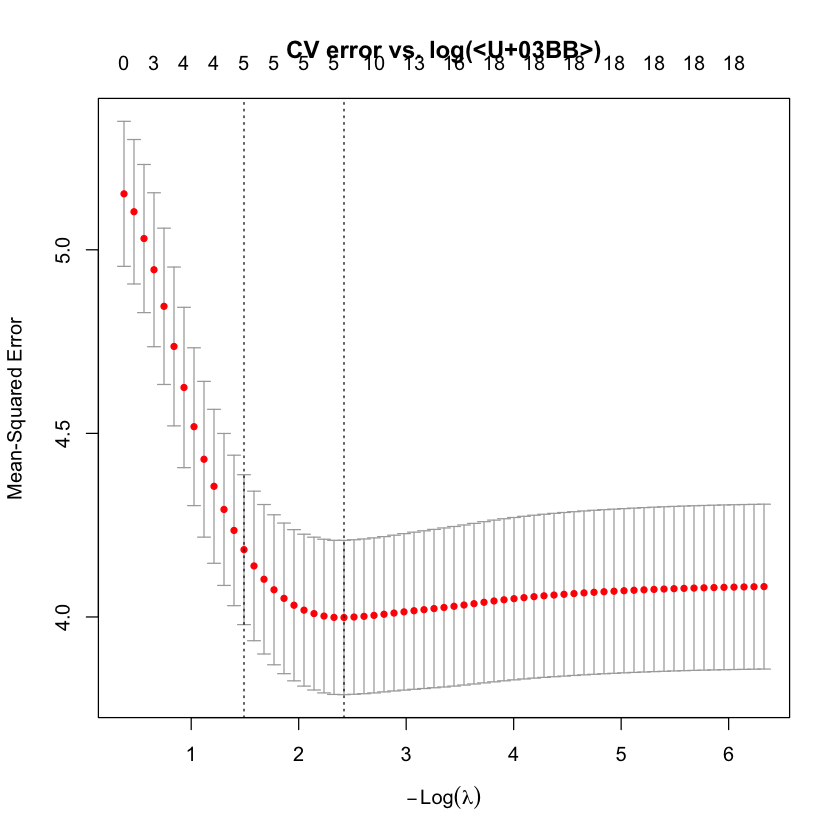

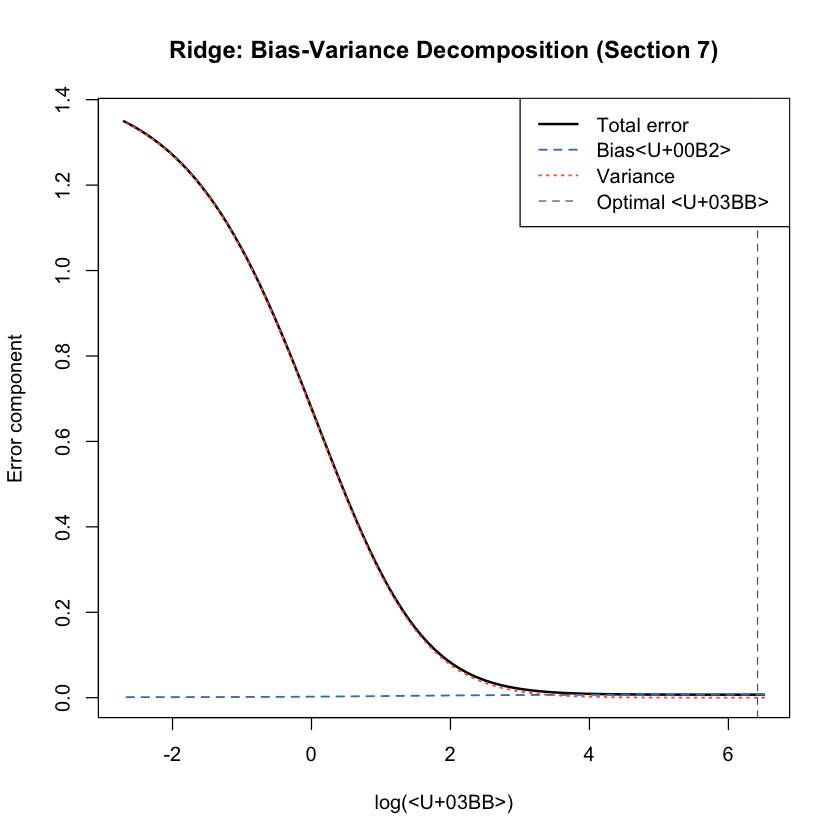

In [ ]:
# sample run

#The block below shows how to chain the functions for a LASSO model on
#simulated data. Uncomment and run to test.

set.seed(42)
N <- 1000; P <- 20
X <- matrix(rnorm(N * P), N, P)
colnames(X) <- paste0("x", 1:P)
beta_true <- c(rep(0.5, 5), rep(0, P - 5))
y <- X %*% beta_true + rnorm(N, sd = 2)

split    <- round(0.7 * N)
x_train  <- X[1:split, ];         y_train <- y[1:split]
x_test   <- X[(split+1):N, ];     y_test  <- y[(split+1):N]

cv_fit   <- select_lasso_lambda(x_train, y_train, nfolds = 5)
selected <- summarise_lasso_selection(cv_fit, colnames(X))
y_hat    <- predict(cv_fit, x_test, s = "lambda.1se")
compute_mse(y_test, y_hat)
compute_rmse_mae(y_test, y_hat, label = "LASSO")
compute_oos_r2(y_test, y_hat)
compute_hit_ratio(y_test, y_hat)


fit_ridge <- glmnet::glmnet(x_train, y_train, alpha = 0)
ridge_bias_variance(fit_ridge, x_test, y_test)
